In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import geopandas as gpd
import contextily as cx
import zipfile
import mapclassify
import folium
import re

file_path = r"C:\Users\jvkim\OneDrive\Desktop\California-Voting-District-Project"

tl_2025_06_tabblock20.zip from https://redistrictingdatahub.org/download/?datasetid=53726&document=%2Fweb_ready_stage%2Fvoterfile%2F2024+GEN+%26+PRI+Non-SPLC+States%2FCA_l2_2024_gen_stats_2020block.zip

In [3]:
with zipfile.ZipFile(file_path + r"\Data\ca_pl2020_official.zip") as ca_pl2020:
    ca_pl2020.extractall("Data")
    ca_pl2020.close()

In [4]:
ca_pl94 = pd.read_csv(file_path + r"\Data\state_PL94_2020_Adjusted_P24_DOJ_Block_csv\state_PL94_2020_Adjusted_P24_DOJ_Block.csv")
ca_blocks = gpd.read_file(file_path + r"\Data\tl_2025_06_tabblock20.zip")
ca_cd118 = pd.read_csv(file_path + r"\Data\06_CA_CD118.txt")
ca_2025 = pd.read_csv(file_path + r"\Data\ab604.csv")
voter_file = pd.read_csv(file_path + r"\Data\CA_l2_2024_gen_stats_2020block\CA_l2_2024_gen_stats_2020block.csv")

C:\Users\jvkim\AppData\Local\Temp\ipykernel_7388\357099291.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  voter_file = pd.read_csv(file_path + r"\Data\CA_l2_2024_gen_stats_2020block\CA_l2_2024_gen_stats_2020block.csv")


<Axes: >

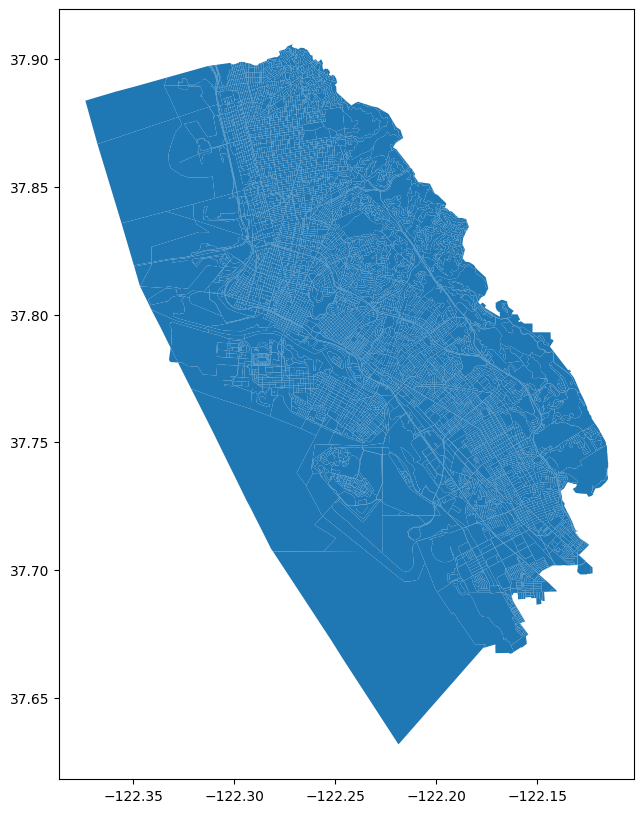

In [5]:
ca_blocks["GEOID20"] = ca_blocks["GEOID20"].astype(int)
ca_blocks_district = ca_blocks.merge(ca_cd118, left_on="GEOID20",right_on= "GEOID", how="left")
ca_blocks_district = ca_blocks_district.rename(columns={"CDFP":"2020 District"})
ca_blocks_district = ca_blocks_district.merge(ca_2025, left_on="GEOID20",right_on= "GEOID", how="left")
ca_blocks_district = ca_blocks_district.drop(["GEOID_x", "GEOID_y"], axis=1)
ca_blocks_district = ca_blocks_district.rename(columns={"CDFP":"2025 District"})


#ca_blocks_district[ca_blocks_district["2020 District"] == 12].explore()
ca_blocks_district[ca_blocks_district["2020 District"] == 12].plot(figsize=(10, 10))

In [6]:
ca_block_demo = ca_blocks_district.merge(ca_pl94, left_on="GEOID20",right_on= "BLOCK20", how="left")
ca_block_demo_filtered = ca_block_demo[ca_block_demo["Population P2"]>0]

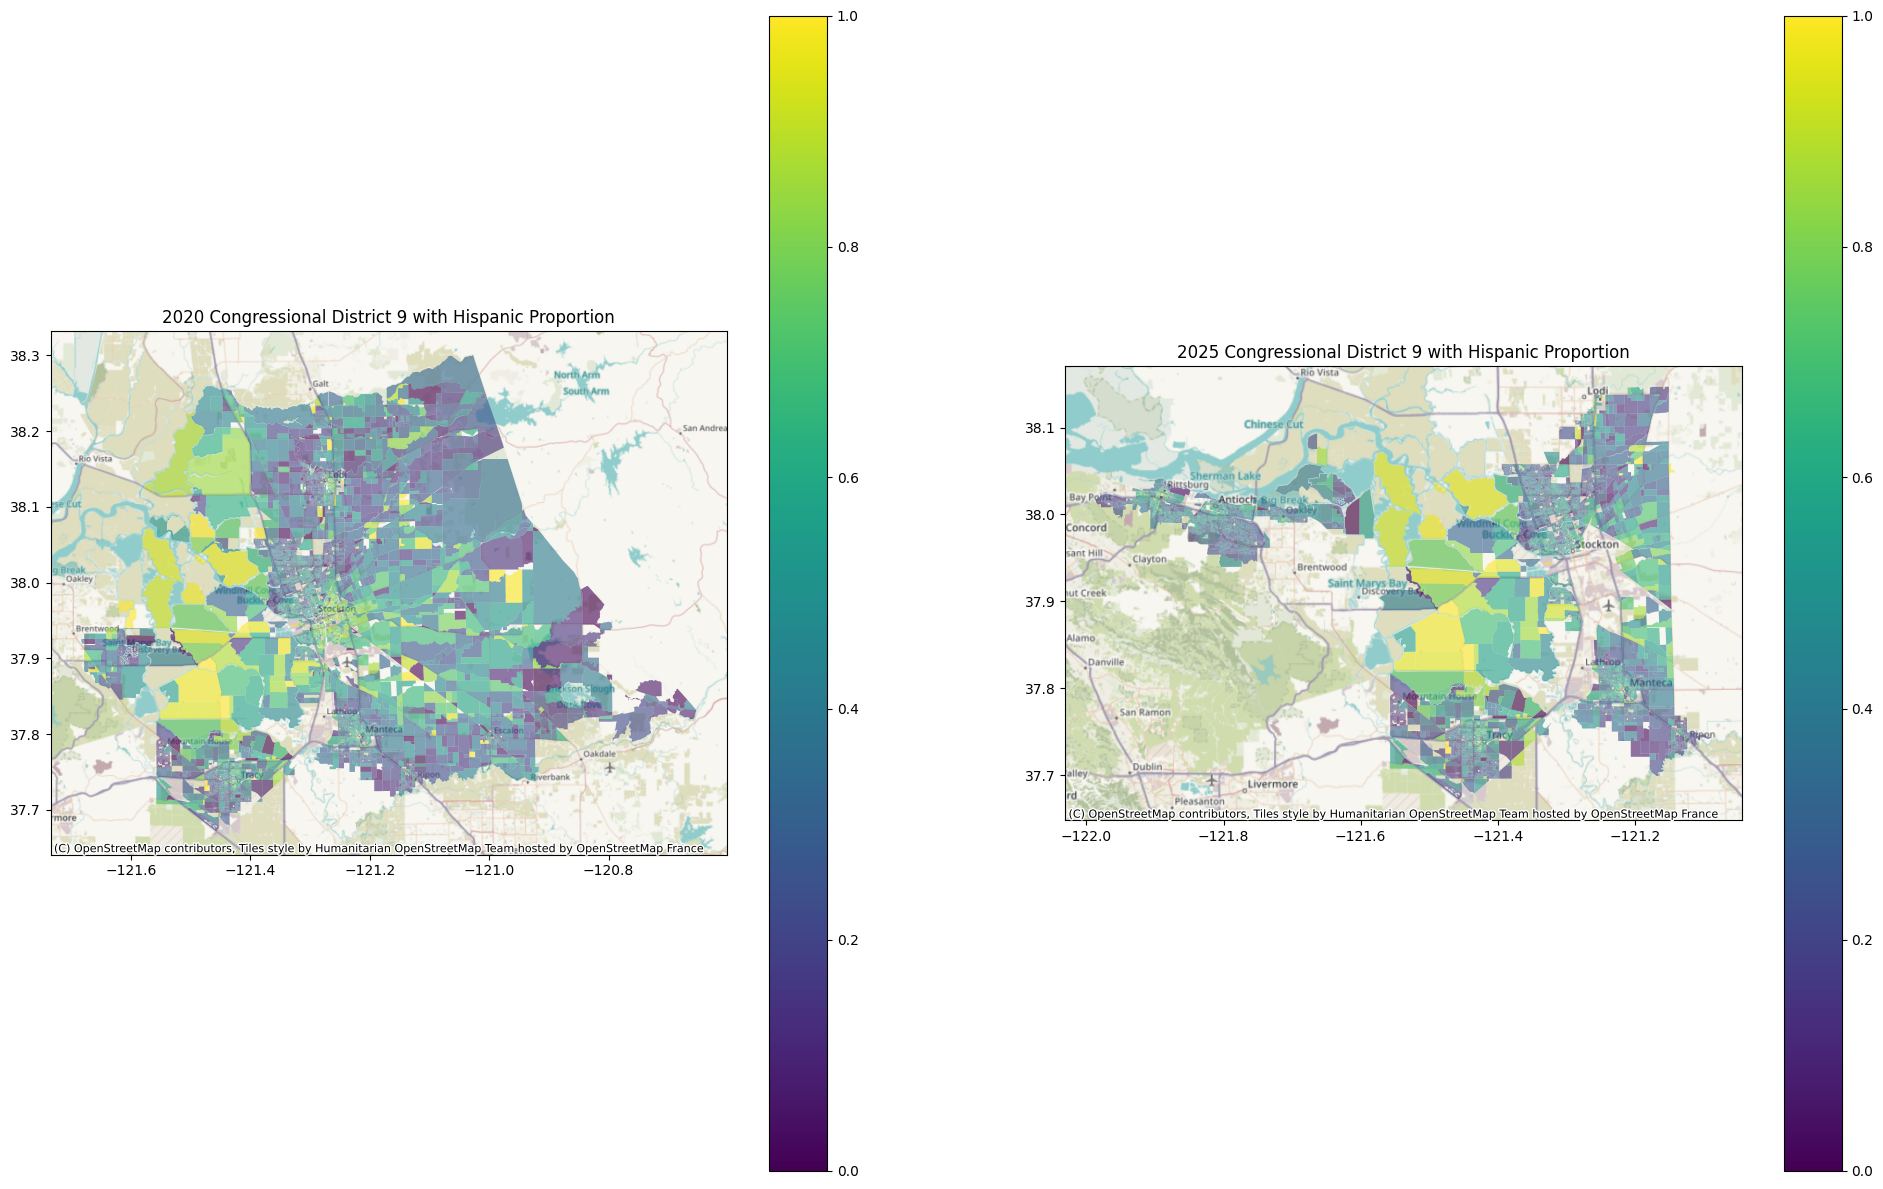

In [34]:
def district_compare(district):
    assert (district > 0 and district<=52), "Invalid district number"
    hispanic_2020 = ca_block_demo_filtered[["GEOID20", "geometry", "Population P2", "Hispanic Origin","2020 District","2025 District", "COUNTYFP20"]][ca_block_demo_filtered["2020 District"] == district]
    hispanic_2020["Hispanic Proportion"] = hispanic_2020["Hispanic Origin"] / hispanic_2020["Population P2"]
    hispanic_2025 = ca_block_demo_filtered[["GEOID20", "geometry", "Population P2", "Hispanic Origin","2020 District","2025 District", "COUNTYFP20"]][ca_block_demo_filtered["2025 District"] == district]
    hispanic_2025["Hispanic Proportion"] = hispanic_2025["Hispanic Origin"] / hispanic_2025["Population P2"]

    fig, axs = plt.subplots(ncols=2,nrows=1, figsize=(24, 15))

    hispanic_2020.plot("Hispanic Proportion", legend=True, ax=axs[0], alpha = 0.6)
    cx.add_basemap(crs=hispanic_2020.crs, ax = axs[0])
    axs[0].set_title(f"2020 Congressional District {district} with Hispanic Proportion")

    hispanic_2025.plot("Hispanic Proportion", legend=True, ax=axs[1], alpha = 0.6)
    cx.add_basemap(crs=hispanic_2025.crs, ax = axs[1])
    axs[1].set_title(f"2025 Congressional District {district} with Hispanic Proportion")

district_compare(9)

Text(0.5, 1.0, "Distribution of Census Blocks in California's 2025 12th District by Hispanic Proportion")

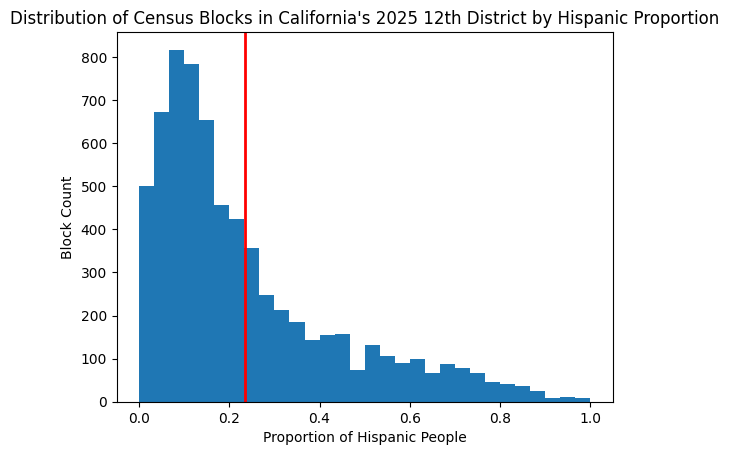

In [8]:
hispanic_12th_2025 = ca_block_demo_filtered[["GEOID20", "geometry", "Population P2", "Hispanic Origin","2020 District","2025 District", "COUNTYFP20"]][ca_block_demo_filtered["2025 District"] == 12]
hispanic_12th_2025["Hispanic Proportion"] = hispanic_12th_2025["Hispanic Origin"] / hispanic_12th_2025["Population P2"]
plt.hist(hispanic_12th_2025["Hispanic Proportion"], bins = 30)
plt.axvline(np.average(hispanic_12th_2025["Hispanic Proportion"]), linewidth=2, color='r')

plt.xlabel("Proportion of Hispanic People")
plt.ylabel("Block Count")
plt.title("Distribution of Census Blocks in California's 2025 12th District by Hispanic Proportion")

In [8]:
#Combines California demographic information by Congressional District
district_demo_2020 = ca_block_demo[["geometry", "Population P2", "Hispanic Origin","2020 District"]].dissolve(by="2020 District",aggfunc='sum')
district_demo_2025 = ca_block_demo[["geometry", "Population P2", "Hispanic Origin", "2025 District"]].dissolve(by="2025 District",aggfunc='sum')

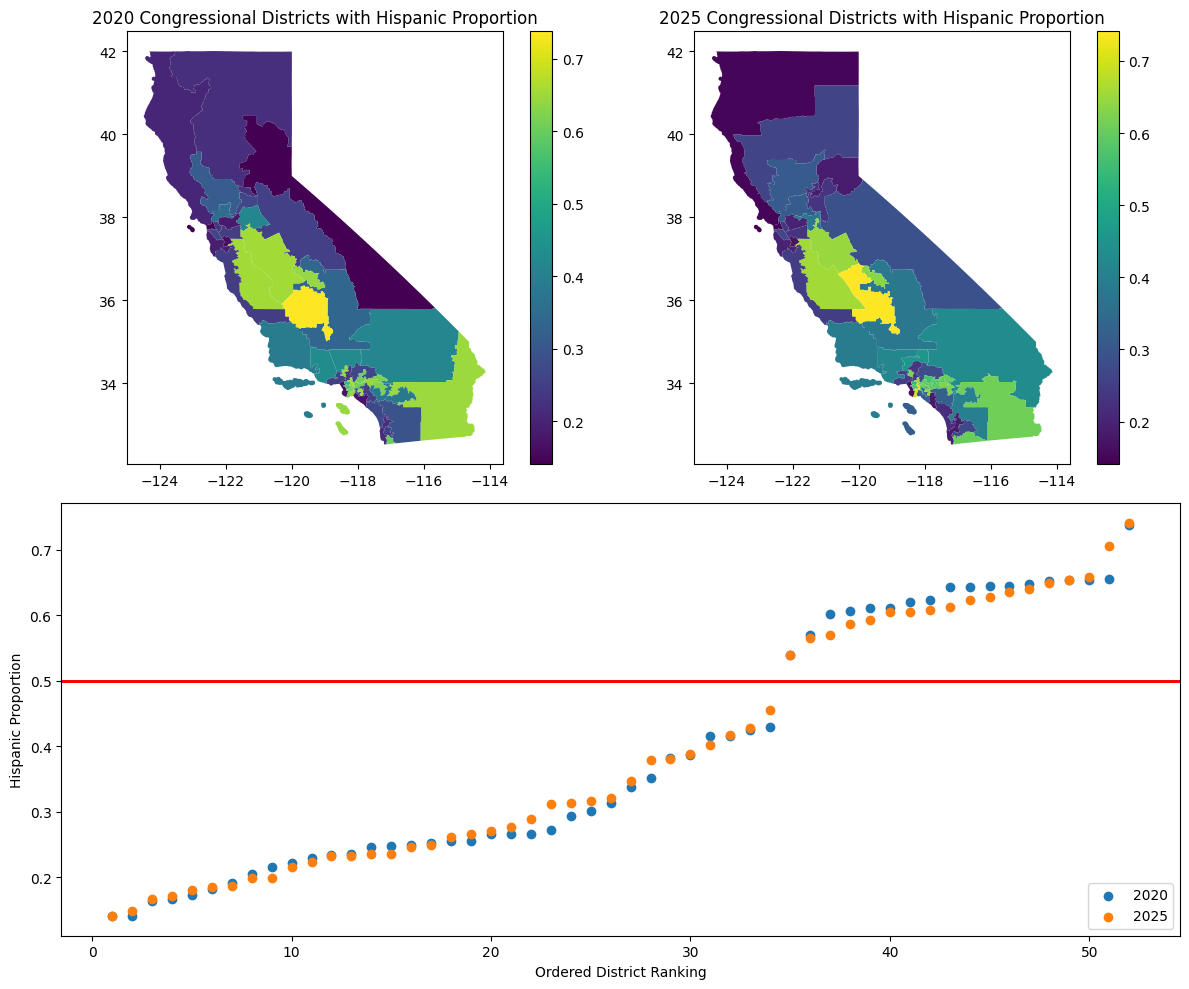

In [9]:
hispanic_district_demo_2020 = district_demo_2020.copy()
hispanic_district_demo_2020["Hispanic Proportion"] = hispanic_district_demo_2020["Hispanic Origin"] / hispanic_district_demo_2020["Population P2"]
hispanic_district_demo_2025 = district_demo_2025.copy()
hispanic_district_demo_2025["Hispanic Proportion"] = hispanic_district_demo_2025["Hispanic Origin"] / hispanic_district_demo_2025["Population P2"]

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(ncols=2, nrows=2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

#2020 Districts
hispanic_district_demo_2020.plot("Hispanic Proportion", legend=True, ax=ax1) 
ax1.set_title("2020 Congressional Districts with Hispanic Proportion")

ax3.scatter(x=np.arange(1, 53, 1), y=hispanic_district_demo_2020["Hispanic Proportion"].sort_values(), label = "2020")
ax3.axhline(0.5, linewidth=2, color='r')
ax3.set_xlabel("Ordered District Ranking")
ax3.set_ylabel("Hispanic Proportion")

#2025 Districts
hispanic_district_demo_2025.plot("Hispanic Proportion", legend=True, ax=ax2) 
ax2.set_title("2025 Congressional Districts with Hispanic Proportion")

ax3.scatter(x=np.arange(1, 53, 1), y=hispanic_district_demo_2025["Hispanic Proportion"].sort_values(), label = "2025")
ax3.axhline(0.5, linewidth=2, color='r')
ax3.set_xlabel("Ordered District Ranking")
ax3.set_ylabel("Hispanic Proportion")
ax3.legend(loc="lower right")

plt.tight_layout()